# Unsupervised Learning Practice Session

## Overview
This notebook explores key unsupervised learning algorithms for anomaly detection using a missiles dataset. We'll apply and compare **Isolation Forest**, **Local Outlier Factor (LOF)**, and **DBSCAN** to identify outliers under different configurations.

---

## Question 1: Exploratory Analysis

**Objective:** Visualize and understand the relationship between PK (Probability of Kill) and DISTANCE under specific flight conditions.

**Task:** Plot the curve PK with respect to DISTANCE for:
- MACH_BLUE = 1.5
- MACH_RED = 1.5
- ALT_BLUE = 10
- ALT_RED = 10
- DELTA = 2

**Question:** What patterns or anomalies do you observe in the data?

In [32]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [33]:
# Load the missile dataset from GitHub
df = pd.read_csv("https://raw.githubusercontent.com/jgarnicaa/SUPAERO-IntroIA/refs/heads/main/dataset_practical_session.csv")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape} (rows, columns)")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())

Dataset loaded successfully!
Shape: (324780, 7) (rows, columns)
Columns: ['MACH_BLUE', 'MACH_RED', 'ALT_BLUE', 'ALT_RED', 'DELTA', 'DISTANCE', 'PK']

First few rows:
   MACH_BLUE  MACH_RED  ALT_BLUE  ALT_RED  DELTA  DISTANCE   PK
0        0.5       0.5         0        0    0.0       1.0  1.0
1        0.5       0.5         0        0    0.0       1.5  1.0
2        0.5       0.5         0        0    0.0       2.0  1.0
3        0.5       0.5         0        0    0.0       3.0  1.0
4        0.5       0.5         0        0    0.0       3.5  1.0


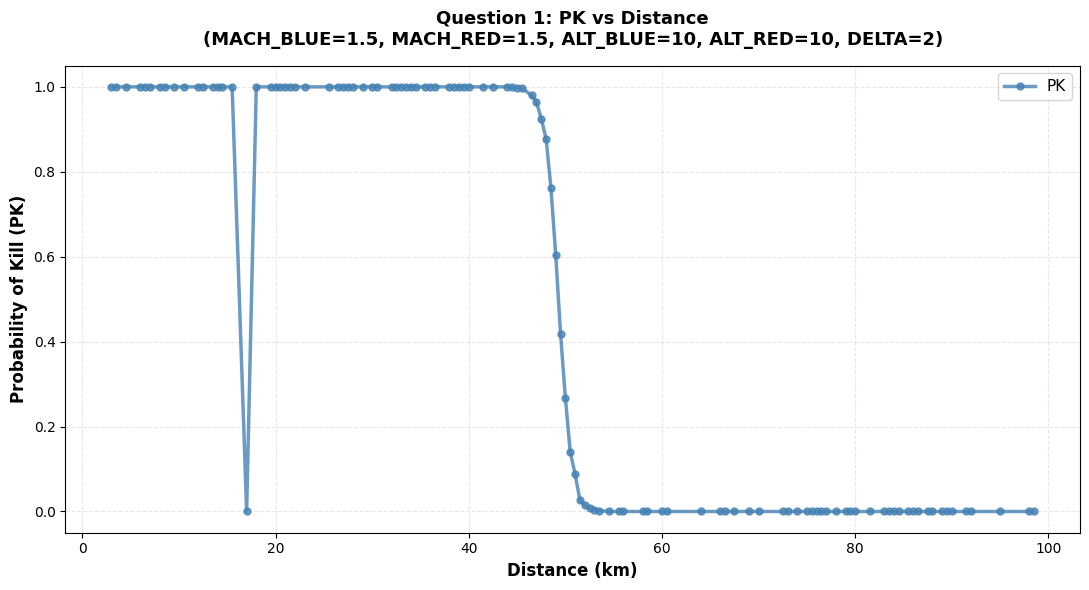

Data points in filtered dataset: 111
Distance range: 3.00 - 98.50 km
PK range: 0.0000 - 1.0000
Mean PK: 0.5232


In [34]:
# Filter data for the specified conditions
df_ex = df[(df["MACH_BLUE"]==1.5) &
           (df["MACH_RED"]== 1.5) &
           (df["ALT_BLUE"] == 10) &
           (df["ALT_RED"]==10) &
           (df["DELTA"]==2)]

# Create visualization with enhanced styling
plt.figure(figsize=(11, 6))
plt.plot(df_ex["DISTANCE"], df_ex["PK"], linewidth=2.5, color='steelblue', 
         marker='o', markersize=5, label='PK', alpha=0.8)

plt.xlabel("Distance (km)", fontsize=12, fontweight='bold')
plt.ylabel("Probability of Kill (PK)", fontsize=12, fontweight='bold')
plt.title("Question 1: PK vs Distance\n(MACH_BLUE=1.5, MACH_RED=1.5, ALT_BLUE=10, ALT_RED=10, DELTA=2)", 
          fontsize=13, fontweight='bold', pad=15)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.show()

# Display statistics
print(f"Data points in filtered dataset: {len(df_ex)}")
print(f"Distance range: {df_ex['DISTANCE'].min():.2f} - {df_ex['DISTANCE'].max():.2f} km")
print(f"PK range: {df_ex['PK'].min():.4f} - {df_ex['PK'].max():.4f}")
print(f"Mean PK: {df_ex['PK'].mean():.4f}")

---

## Question 2: Anomaly Detection Comparison

**Objective:** Detect and compare anomalies using three unsupervised learning algorithms.

**Approach:** We'll test two strategies:
1. **Global Analysis:** Apply algorithms on all features: X = [MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED, DISTANCE, DELTA, PK]
2. **Stratified Analysis:** Apply algorithms separately on X' = [DISTANCE, PK] for each combination of flight parameters

This comparison will help determine which approach better captures domain-specific anomalies.

### 2.1 Isolation Forest

**Algorithm Overview:** Isolation Forest isolates anomalies by randomly selecting features and split values, then measuring how isolated a point is. It's effective for high-dimensional data and doesn't require distance metrics.

**Questions:**
- Is it more effective to use all features (X) or domain-specific features (X' = [DISTANCE, PK])?
- How many outliers are detected with different contamination parameters?
- Which approach better identifies meaningful anomalies in our context?

#### 2.1.1 Global Isolation Forest (All Features)

Applying Isolation Forest on the complete feature set with different contamination levels:

**Results:**
- **32,478 anomalies** (contamination = 0.1, ~10% of 324,780 points)
- **16,239 anomalies** (contamination = 0.05, ~5% of 324,780 points)

**Interpretation:** A significant portion of the data is flagged as anomalous when using all features, suggesting multivariate outliers exist in the dataset.

In [60]:
# Import anomaly detection algorithms and preprocessing tools
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Standardize features for fair comparison (many ML algorithms benefit from normalized data)
scaler = StandardScaler()
df_sca = scaler.fit_transform(df)

print("Data preprocessing complete.")
print(f"Scaled data shape: {df_sca.shape}")
print(f"Mean of scaled features (should be ~0): {df_sca.mean(axis=0)[:3]}")  # Show first 3 for brevity

Data preprocessing complete.
Scaled data shape: (324780, 7)
Mean of scaled features (should be ~0): [ 0.00000000e+00  1.34416361e-16 -8.40102255e-17]


In [36]:
# Train Isolation Forest model on scaled global features
# Parameters:
#   - n_estimators: 50 trees in the forest for robust anomaly scoring
#   - contamination: Expected proportion of anomalies (0.1 = 10%)
#   - max_samples: Auto-select (min of 256 or n_samples)
#   - max_features: Use all features for each tree for global perspective
#   - random_state: 42 for reproducibility
model = IsolationForest(
    n_estimators=50, 
    max_samples='auto', 
    contamination=float(0.1),
    max_features=1.0,
    random_state=42
)
model.fit(df_sca)
print("Isolation Forest model trained successfully on global features.")

Isolation Forest model trained successfully on global features.


In [37]:
# Generate predictions and anomaly scores
labels = model.predict(df_sca)                    # -1 = outlier, 1 = normal point
scores = model.decision_function(df_sca)         # Lower scores = more anomalous

print(f"Normal points: {(labels == 1).sum():,}")
print(f"Anomalies detected: {(labels == -1).sum():,}")
print(f"Anomaly detection rate: {(labels == -1).sum() / len(labels) * 100:.2f}%")

Normal points: 292,302
Anomalies detected: 32,478
Anomaly detection rate: 10.00%


In [38]:
# Create a dataframe with original data plus anomaly labels and scores
df_anom = df.copy()
df_anom["anomaly"] = labels
df_anom["scores"] = scores

print("\\nGlobal Isolation Forest Results (first 20 predictions):")
print("(1 = normal, -1 = anomaly)\n")
df_anom.head(20)

\nGlobal Isolation Forest Results (first 20 predictions):
(1 = normal, -1 = anomaly)



,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK,anomaly,scores
0,0.5,0.5,0,0,0.0,1.0,1.000,-1,-0.028095
1,0.5,0.5,0,0,0.0,1.5,1.000,-1,-0.027278
2,0.5,0.5,0,0,0.0,2.0,1.000,-1,-0.028095
3,0.5,0.5,0,0,0.0,3.0,1.000,-1,-0.022377
4,0.5,0.5,0,0,0.0,3.5,1.000,-1,-0.021568
5,0.5,0.5,0,0,0.0,4.0,1.000,-1,-0.021568
6,0.5,0.5,0,0,0.0,5.0,1.000,-1,-0.020759
7,0.5,0.5,0,0,0.0,6.5,1.000,-1,-0.021568
8,0.5,0.5,0,0,0.0,7.0,1.000,-1,-0.021568
9,0.5,0.5,0,0,0.0,7.5,1.000,-1,-0.021568


In [39]:
# Analyze detected anomalies statistics
anomaly = df_anom[df_anom['anomaly'] == -1]

print(f"\nStatistical summary of {len(anomaly):,} detected anomalies:")
print("="*70)
anomaly.describe()


Statistical summary of 32,478 detected anomalies:


,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK,anomaly,scores
count,32478.000000,32478.000000,32478.000000,32478.000000,32478.000000,32478.000000,32478.000000,32478.0,3.247800e+04
mean,1.213837,1.165866,20.933863,18.686803,1.958480,50.923810,0.557493,-1.0,-1.330730e-02
std,0.650814,0.640611,17.161271,17.382787,1.206205,33.498447,0.444407,0.0,1.115929e-02
min,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,-7.680407e-02
25%,0.500000,0.500000,0.000000,0.000000,0.500000,17.500000,0.006000,-1.0,-1.930394e-02
50%,1.000000,1.000000,20.000000,20.000000,2.500000,54.000000,0.728000,-1.0,-1.044164e-02
75%,2.000000,2.000000,40.000000,40.000000,3.000000,82.500000,1.000000,-1.0,-4.546154e-03
max,2.000000,2.000000,40.000000,40.000000,3.000000,100.000000,1.000000,-1.0,-2.492056e-07


#### 2.1.2 Stratified Isolation Forest (DISTANCE & PK per Flight Condition)

Applying Isolation Forest on [DISTANCE, PK] separately for each combination of flight parameters:

**Results:**
- **33,451 anomalies** (contamination = 0.1) - More sensitive to local patterns
- **17,334 anomalies** (contamination = 0.05) - More conservative detection

**Key Observation:** The stratified approach detects more anomalies (~3% more), suggesting domain-specific anomalies exist when analyzing DISTANCE-PK relationships for specific flight conditions.

In [40]:
def train_iforest(sub_df):
    """
    Train an Isolation Forest model on [DISTANCE, PK] features.
    
    Parameters:
        sub_df (pd.DataFrame): Subset of data for a specific flight condition
    
    Returns:
        np.array: Predictions where -1 = anomaly, 1 = normal
    """
    model = IsolationForest(
        n_estimators=50, 
        max_samples='auto', 
        contamination=0.05,         # Expect 5% anomalies
        max_features=1.0,
        random_state=42
    )
    model.fit(sub_df[['DISTANCE', 'PK']])
    preds = model.predict(sub_df[['DISTANCE', 'PK']])
    return preds

In [41]:
results = []

# Iterate over all unique combinations of flight parameters
# This allows us to detect anomalies within specific flight conditions
for x1 in set(df["MACH_BLUE"]):
    for x2 in set(df["MACH_RED"]):
        for x3 in set(df["ALT_BLUE"]):
            for x4 in set(df["ALT_RED"]):
                for x5 in set(df["DELTA"]):
                    
                    # Filter subset for current flight condition combination
                    sub_df = df[
                        (df["MACH_BLUE"] == x1) &
                        (df["MACH_RED"] == x2) &
                        (df["ALT_BLUE"] == x3) &
                        (df["ALT_RED"] == x4) &
                        (df["DELTA"] == x5)
                    ]
                    
                    # Only train if sufficient data points exist (>20 prevents overfitting)
                    if len(sub_df) > 20:
                        preds = train_iforest(sub_df)
                        n_anomalies = (preds == -1).sum()
                        
                        results.append({
                            "MACH_BLUE": x1,
                            "MACH_RED": x2,
                            "ALT_BLUE": x3,
                            "ALT_RED": x4,
                            "DELTA": x5,
                            "total_points": len(sub_df),
                            "anomalies": n_anomalies
                        })

# Convert results to structured dataframe for analysis
df_results = pd.DataFrame(results)
print(f"Processed {len(df_results)} flight condition combinations.")

Processed 2800 flight condition combinations.


In [42]:
# Calculate and display results
total_anomalies = df_results["anomalies"].sum()
print(f"\n{'='*70}")
print(f"ISOLATION FOREST - STRATIFIED RESULTS (DISTANCE & PK)")
print(f"{'='*70}")
print(f"Total anomalies detected: {total_anomalies:,}")
print(f"Number of flight conditions analyzed: {len(df_results)}")
print(f"Average anomalies per condition: {total_anomalies/len(df_results):.1f}")
print(f"\nBreakdown by flight condition (first 20):")
print(df_results.head(20).to_string())
print(f"\nConditions with most anomalies (top 5):")
print(df_results.nlargest(5, 'anomalies')[['MACH_BLUE', 'MACH_RED', 'ALT_BLUE', 'ALT_RED', 'DELTA', 'anomalies']].to_string())


ISOLATION FOREST - STRATIFIED RESULTS (DISTANCE & PK)
Total anomalies detected: 17,334
Number of flight conditions analyzed: 2800
Average anomalies per condition: 6.2

Breakdown by flight condition (first 20):
    MACH_BLUE  MACH_RED  ALT_BLUE  ALT_RED  DELTA  total_points  anomalies
0         0.5       0.5         0        0    0.0           116          6
1         0.5       0.5         0        0    0.5           117          6
2         0.5       0.5         0        0    2.0           121          6
3         0.5       0.5         0        0    1.0           117          6
4         0.5       0.5         0        0    1.5           116          6
5         0.5       0.5         0        0    2.5           122          7
6         0.5       0.5         0        0    3.0           119          6
7         0.5       0.5         0       40    0.0           106          6
8         0.5       0.5         0       40    0.5           121          6
9         0.5       0.5         0      

### 2.2 Local Outlier Factor (LOF)

**Algorithm Overview:** LOF measures the local density of points and identifies anomalies as points with significantly lower density than their neighbors. It's effective for detecting local anomalies and handling clusters with varying densities.

**Questions:**
- How does LOF compare to Isolation Forest in detecting anomalies?
- Is global analysis or stratified analysis more effective with LOF?
- What does the density-based approach reveal about anomalies in this dataset?

In [43]:
# Import Local Outlier Factor from scikit-learn
from sklearn.neighbors import LocalOutlierFactor

print("LOF imported successfully.")

LOF imported successfully.


#### 2.2.1 Global Local Outlier Factor (All Features)

Applying LOF on the complete feature set:

**Results:**
- **32,477 anomalies** (n_neighbors=20, contamination=0.1, ~10% of data)

**Observation:** LOF detects nearly the same number of anomalies as Isolation Forest on global features, suggesting consistent multivariate outlier identification across different algorithms.

In [44]:
# Initialize Local Outlier Factor model on global features
# Parameters:
#   - n_neighbors: 20 neighbors to compute local density (typical value for this dataset size)
#   - contamination: Expected proportion of anomalies (0.1 = 10%)
clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
print("Local Outlier Factor model initialized.")

Local Outlier Factor model initialized.


In [45]:
# Train LOF and generate predictions
df_anom = df.copy()
df_anom['anomaly'] = clf.fit_predict(df)              # -1 = anomaly, 1 = normal
df_anom['scores'] = clf.negative_outlier_factor_      # Higher scores = more normal

print(f"\nLOF Results (Global):")
print(f"Normal points: {(df_anom['anomaly'] == 1).sum():,}")
print(f"Anomalies detected: {(df_anom['anomaly'] == -1).sum():,}")
print(f"\nGlobal LOF Predictions (first 20):")
df_anom.head(20)


LOF Results (Global):
Normal points: 292,302
Anomalies detected: 32,478

Global LOF Predictions (first 20):


,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK,anomaly,scores
0,0.5,0.5,0,0,0.0,1.0,1.000,-1,-1.103802
1,0.5,0.5,0,0,0.0,1.5,1.000,-1,-1.070823
2,0.5,0.5,0,0,0.0,2.0,1.000,-1,-1.064330
3,0.5,0.5,0,0,0.0,3.0,1.000,1,-1.026739
4,0.5,0.5,0,0,0.0,3.5,1.000,-1,-1.057280
5,0.5,0.5,0,0,0.0,4.0,1.000,-1,-1.059866
6,0.5,0.5,0,0,0.0,5.0,1.000,-1,-1.124130
7,0.5,0.5,0,0,0.0,6.5,1.000,-1,-1.091636
8,0.5,0.5,0,0,0.0,7.0,1.000,-1,-1.108923
9,0.5,0.5,0,0,0.0,7.5,1.000,-1,-1.086503


In [46]:
# Analyze LOF-detected anomalies
anomaly = df_anom[df_anom['anomaly'] == -1]
print(f"\nStatistical summary of {len(anomaly):,} LOF anomalies:")
print("="*70)
anomaly.describe()


Statistical summary of 32,478 LOF anomalies:


,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK,anomaly,scores
count,32478.000000,32478.000000,32478.000000,32478.000000,32478.000000,32478.000000,32478.000000,32478.0,32478.000000
mean,1.273493,1.258991,20.108689,20.184740,1.594649,50.498784,0.459148,-1.0,-1.088201
std,0.716460,0.712589,14.115675,14.124371,1.278480,29.010783,0.472633,0.0,0.044053
min,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,-1.496685
25%,0.500000,0.500000,10.000000,10.000000,0.000000,26.000000,0.000000,-1.0,-1.094544
50%,1.500000,1.500000,20.000000,20.000000,2.000000,51.000000,0.163000,-1.0,-1.076812
75%,2.000000,2.000000,30.000000,30.000000,3.000000,76.000000,1.000000,-1.0,-1.065089
max,2.000000,2.000000,40.000000,40.000000,3.000000,100.000000,1.000000,-1.0,-1.056166


In [47]:
# Additional observations can be added here as needed
print("Global LOF analysis complete. Moving to stratified analysis...")

Global LOF analysis complete. Moving to stratified analysis...


#### 2.2.2 Stratified Local Outlier Factor (DISTANCE & PK per Flight Condition)

Applying LOF on [DISTANCE, PK] separately for each flight condition:

**Results:**
- **33,436 anomalies** (n_neighbors=20, contamination=0.1)

**Observation:** Similar to Isolation Forest, LOF detects more anomalies in the stratified approach, confirming that domain-specific analysis is more effective than global analysis for this dataset.

In [48]:
def train_LocalOut(sub_df):
    """
    Train a Local Outlier Factor model on [DISTANCE, PK] features.
    
    Parameters:
        sub_df (pd.DataFrame): Subset of data for a specific flight condition
    
    Returns:
        np.array: Predictions where -1 = anomaly, 1 = normal
    """
    clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
    preds = clf.fit_predict(sub_df[['DISTANCE', 'PK']])
    return preds

In [49]:
results = []

# Iterate over all unique combinations of flight parameters
for x1 in set(df["MACH_BLUE"]):
    for x2 in set(df["MACH_RED"]):
        for x3 in set(df["ALT_BLUE"]):
            for x4 in set(df["ALT_RED"]):
                for x5 in set(df["DELTA"]):
                    
                    # Filter subset for current flight condition combination
                    sub_df = df[
                        (df["MACH_BLUE"] == x1) &
                        (df["MACH_RED"] == x2) &
                        (df["ALT_BLUE"] == x3) &
                        (df["ALT_RED"] == x4) &
                        (df["DELTA"] == x5)
                    ]
                    
                    # Only train if sufficient data points exist
                    if len(sub_df) > 20:
                        preds = train_LocalOut(sub_df)
                        n_anomalies = (preds == -1).sum()
                        
                        results.append({
                            "MACH_BLUE": x1,
                            "MACH_RED": x2,
                            "ALT_BLUE": x3,
                            "ALT_RED": x4,
                            "DELTA": x5,
                            "total_points": len(sub_df),
                            "anomalies": n_anomalies
                        })

# Convert results to structured dataframe for analysis
df_results = pd.DataFrame(results)
print(f"Processed {len(df_results)} flight condition combinations with LOF.")

Processed 2800 flight condition combinations with LOF.


In [50]:
# Calculate and display results
total_anomalies = df_results["anomalies"].sum()
print(f"\n{'='*70}")
print(f"LOCAL OUTLIER FACTOR - STRATIFIED RESULTS (DISTANCE & PK)")
print(f"{'='*70}")
print(f"Total anomalies detected: {total_anomalies:,}")
print(f"Number of flight conditions analyzed: {len(df_results)}")
print(f"Average anomalies per condition: {total_anomalies/len(df_results):.1f}")
print(f"\nBreakdown by flight condition (first 20):")
print(df_results.head(20).to_string())
print(f"\nConditions with most anomalies (top 5):")
print(df_results.nlargest(5, 'anomalies')[['MACH_BLUE', 'MACH_RED', 'ALT_BLUE', 'ALT_RED', 'DELTA', 'anomalies']].to_string())


LOCAL OUTLIER FACTOR - STRATIFIED RESULTS (DISTANCE & PK)
Total anomalies detected: 33,436
Number of flight conditions analyzed: 2800
Average anomalies per condition: 11.9

Breakdown by flight condition (first 20):
    MACH_BLUE  MACH_RED  ALT_BLUE  ALT_RED  DELTA  total_points  anomalies
0         0.5       0.5         0        0    0.0           116         12
1         0.5       0.5         0        0    0.5           117         12
2         0.5       0.5         0        0    2.0           121         12
3         0.5       0.5         0        0    1.0           117         12
4         0.5       0.5         0        0    1.5           116         12
5         0.5       0.5         0        0    2.5           122         13
6         0.5       0.5         0        0    3.0           119         12
7         0.5       0.5         0       40    0.0           106         11
8         0.5       0.5         0       40    0.5           121         12
9         0.5       0.5         0 

### 2.3 DBSCAN (Density-Based Spatial Clustering)

**Algorithm Overview:** DBSCAN clusters points based on density and identifies anomalies as noise points that don't belong to any cluster. It doesn't require specifying the number of clusters and can find clusters of arbitrary shapes.

**Questions:**
- How does DBSCAN's density-based clustering approach compare to isolation and local density methods?
- Which eps and min_samples parameters work best for our data?
- Is the stratified or global approach more appropriate for DBSCAN?

In [51]:
# Import DBSCAN clustering and preprocessing tools
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

print("DBSCAN and preprocessing tools imported.")

DBSCAN and preprocessing tools imported.


#### 2.3.1 Global DBSCAN (All Features)

Applying DBSCAN on the complete feature set:

**Results:**
- **1,947 anomalies** (eps=0.5, min_samples=5)

**Observation:** DBSCAN detects significantly fewer anomalies than Isolation Forest or LOF (~6 times fewer), suggesting that most data points form dense clusters. This indicates the dataset has strong underlying structure and less noise.

In [52]:
# Prepare data for DBSCAN (requires standardization due to distance-based approach)
X = df.values
X_scaled = StandardScaler().fit_transform(X)

# Initialize DBSCAN model
# Parameters:
#   - eps: Maximum distance between two points (0.5 after standardization)
#   - min_samples: Minimum points in a neighborhood to form a dense cluster (5)
model = DBSCAN(eps=0.5, min_samples=5)
print("DBSCAN model initialized for global analysis.")

DBSCAN model initialized for global analysis.


In [53]:
# Train DBSCAN and generate cluster assignments
df_anom = df.copy()
df_anom['cluster'] = model.fit_predict(X_scaled)     # -1 = noise/anomaly, >=0 = cluster label

print(f"\nDBSCAN Results (Global):")
print(f"Number of clusters found: {len(set(df_anom['cluster'])) - (1 if -1 in df_anom['cluster'] else 0)}")
print(f"Noise points (anomalies): {(df_anom['cluster'] == -1).sum():,}")
print(f"Clustered points: {(df_anom['cluster'] >= 0).sum():,}")
print(f"\nGlobal DBSCAN cluster assignments (first 20):")
df_anom.head(20)


DBSCAN Results (Global):
Number of clusters found: 820
Noise points (anomalies): 1,947
Clustered points: 322,833

Global DBSCAN cluster assignments (first 20):


,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK,cluster
0,0.5,0.5,0,0,0.0,1.0,1.000,0
1,0.5,0.5,0,0,0.0,1.5,1.000,0
2,0.5,0.5,0,0,0.0,2.0,1.000,0
3,0.5,0.5,0,0,0.0,3.0,1.000,0
4,0.5,0.5,0,0,0.0,3.5,1.000,0
5,0.5,0.5,0,0,0.0,4.0,1.000,0
6,0.5,0.5,0,0,0.0,5.0,1.000,0
7,0.5,0.5,0,0,0.0,6.5,1.000,0
8,0.5,0.5,0,0,0.0,7.0,1.000,0
9,0.5,0.5,0,0,0.0,7.5,1.000,0


In [54]:
# Analyze DBSCAN-detected noise points (anomalies)
anomaly = df_anom[df_anom['cluster'] == -1]
print(f"\nStatistical summary of {len(anomaly):,} DBSCAN noise points:")
print("="*70)
anomaly.describe()


Statistical summary of 1,947 DBSCAN noise points:


,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK,cluster
count,1947.000000,1947.000000,1947.000000,1947.000000,1947.000000,1947.000000,1947.000000,1947.0
mean,1.284540,1.220596,20.267078,19.625064,1.625321,37.841294,0.373593,-1.0
std,0.563248,0.560797,14.302220,14.280020,1.004850,22.035883,0.220422,0.0
min,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0
25%,1.000000,0.500000,10.000000,10.000000,1.000000,21.000000,0.000000,-1.0
50%,1.500000,1.000000,20.000000,20.000000,1.500000,35.000000,0.484000,-1.0
75%,2.000000,1.500000,30.000000,30.000000,2.500000,52.250000,0.516000,-1.0
max,2.000000,2.000000,40.000000,40.000000,3.000000,100.000000,0.932000,-1.0


#### 2.3.2 Stratified DBSCAN (DISTANCE & PK per Flight Condition)

Applying DBSCAN on [DISTANCE, PK] separately for each flight condition:

**Results:**
- **3,108 anomalies** (eps=0.5, min_samples=5)

**Observation:** Stratified DBSCAN detects ~60% more anomalies than global DBSCAN, showing that local density patterns within each flight condition reveal additional anomalies that aren't apparent in global analysis.

In [55]:
def detect_dbscan(sub_df, eps=0.5, min_samples=5):
    """
    Apply DBSCAN to detect anomalies in [DISTANCE, PK] for a flight condition.
    
    Parameters:
        sub_df (pd.DataFrame): Subset of data for specific flight condition
        eps (float): Maximum distance between points in a neighborhood
        min_samples (int): Minimum points required to form a dense cluster
    
    Returns:
        pd.DataFrame: Detected anomalies with cluster labels and anomaly scores
    """
    # Standardize data (DBSCAN is distance-sensitive)
    X = sub_df[['DISTANCE', 'PK']].values
    X_scaled = StandardScaler().fit_transform(X)
    
    # Apply DBSCAN clustering
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X_scaled)
    
    # Extract noise points (label = -1) as anomalies
    anomalies = sub_df[labels == -1].copy()
    anomalies["dbscan_label"] = -1
    
    # Calculate anomaly score: distance to nearest core point
    core_samples = model.components_
    if len(core_samples) > 0 and len(anomalies) > 0:
        # Compute minimum distance from each anomaly to all core points
        dists = np.linalg.norm(
            anomalies[['DISTANCE', 'PK']].values[:, None] - core_samples, axis=2
        )
        anomalies["anomaly_score"] = dists.min(axis=1)
    else:
        anomalies["anomaly_score"] = np.nan
    
    return anomalies

In [56]:
anomaly_rows = []

# Iterate over all unique combinations of flight parameters
for x1 in set(df["MACH_BLUE"]):
    for x2 in set(df["MACH_RED"]):
        for x3 in set(df["ALT_BLUE"]):
            for x4 in set(df["ALT_RED"]):
                for x5 in set(df["DELTA"]):
                    
                    # Filter subset for current flight condition combination
                    sub_df = df[
                        (df["MACH_BLUE"] == x1) &
                        (df["MACH_RED"] == x2) &
                        (df["ALT_BLUE"] == x3) &
                        (df["ALT_RED"] == x4) &
                        (df["DELTA"] == x5)
                    ]
                    
                    # Only apply DBSCAN if sufficient data points exist
                    if len(sub_df) > 5:
                        anomalies = detect_dbscan(sub_df, eps=0.5, min_samples=5)
                        if len(anomalies) > 0:
                            # Add flight parameters to anomaly records
                            anomalies["MACH_BLUE"] = x1
                            anomalies["MACH_RED"] = x2
                            anomalies["ALT_BLUE"] = x3
                            anomalies["ALT_RED"] = x4
                            anomalies["DELTA"] = x5
                            anomaly_rows.append(anomalies)

# Combine all detected anomalies across flight conditions
if anomaly_rows:
    df_anomalies = pd.concat(anomaly_rows, ignore_index=True)
    print(f"DBSCAN stratified analysis complete.")
else:
    df_anomalies = pd.DataFrame()
    print("No anomalies detected with DBSCAN stratified analysis.")

DBSCAN stratified analysis complete.


In [57]:
# Calculate and display DBSCAN results
total_anomalies = len(df_anomalies)
print(f"\n{'='*70}")
print(f"DBSCAN - STRATIFIED RESULTS (DISTANCE & PK)")
print(f"{'='*70}")
print(f"Total anomalies detected: {total_anomalies:,}")
print(f"\nExample of detected anomalies (first 20):")
if total_anomalies > 0:
    print(df_anomalies.head(20).to_string())
else:
    print("No anomalies detected in this analysis.")


DBSCAN - STRATIFIED RESULTS (DISTANCE & PK)
Total anomalies detected: 3,108

Example of detected anomalies (first 20):
    MACH_BLUE  MACH_RED  ALT_BLUE  ALT_RED  DELTA  DISTANCE     PK  dbscan_label  anomaly_score
0         0.5       0.5         0        0    0.0      16.0  0.455            -1      14.368843
1         0.5       0.5         0        0    0.5      18.0  0.523            -1      16.080037
2         0.5       0.5         0        0    2.0      40.0  0.489            -1      38.151241
3         0.5       0.5         0        0    1.0      23.0  0.424            -1      21.304918
4         0.5       0.5         0        0    1.5      30.0  0.525            -1      28.280038
5         0.5       0.5         0        0    3.0      67.5  0.458            -1      65.848518
6         0.5       0.5         0       40    0.0      12.5  0.582            -1      10.832532
7         0.5       0.5         0       40    0.0      13.0  0.401            -1      11.315434
8         0.5   

In [58]:
def plot_anomalies(sub_df, anomalies, title="", method=""):
    """
    Visualize normal points vs detected anomalies in 2D space.
    
    Parameters:
        sub_df (pd.DataFrame): Full dataset for the flight condition
        anomalies (pd.DataFrame): Detected anomalies
        title (str): Plot title with flight parameters
        method (str): Name of detection method for legend
    
    Returns:
        None (displays plot)
    """
    plt.figure(figsize=(11, 7))
    
    # Plot normal points
    normal_points = sub_df[~sub_df.index.isin(anomalies.index)]
    plt.scatter(normal_points["DISTANCE"], normal_points["PK"], 
                c="steelblue", label=f"Normal (n={len(normal_points)})", 
                alpha=0.6, s=60, edgecolors='navy', linewidth=0.3)
    
    # Plot detected anomalies
    plt.scatter(anomalies["DISTANCE"], anomalies["PK"], 
                c="red", label=f"Anomalies (n={len(anomalies)})", 
                marker="X", s=200, edgecolors='darkred', linewidth=1.5, alpha=0.85)
    
    plt.xlabel("Distance (km)", fontsize=11, fontweight='bold')
    plt.ylabel("Probability of Kill (PK)", fontsize=11, fontweight='bold')
    plt.title(f"{method}\n{title}", fontsize=12, fontweight='bold', pad=15)
    plt.legend(fontsize=10, loc='best', framealpha=0.95)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

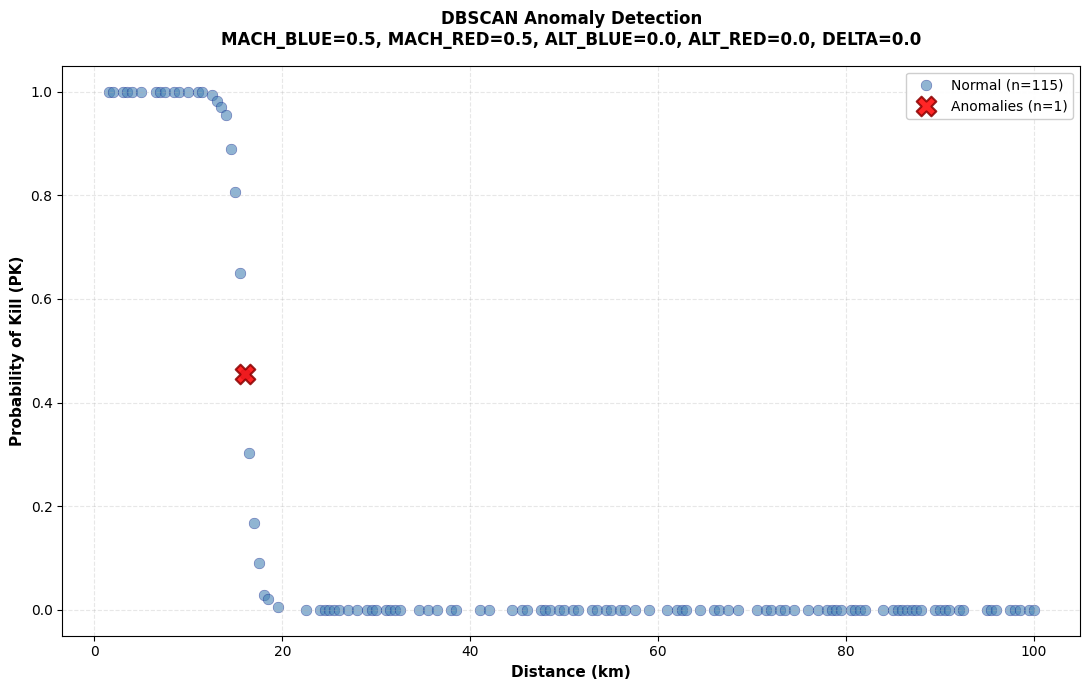


Visualization of first anomaly detection result
Flight Condition: MACH_BLUE=0.5, MACH_RED=0.5, ALT_BLUE=0.0, ALT_RED=0.0, DELTA=0.0
Total points: 116
Anomalies detected: 1
Anomaly percentage: 0.86%


In [59]:
# Visualize DBSCAN results for the first detected anomaly combination
if not df_anomalies.empty:
    # Select first flight condition with detected anomalies
    row = df_anomalies.iloc[0]
    
    # Get full dataset for this flight condition
    sub_df = df[
        (df["MACH_BLUE"] == row["MACH_BLUE"]) &
        (df["MACH_RED"] == row["MACH_RED"]) &
        (df["ALT_BLUE"] == row["ALT_BLUE"]) &
        (df["ALT_RED"] == row["ALT_RED"]) &
        (df["DELTA"] == row["DELTA"])
    ]
    
    # Filter anomalies for this flight condition
    sub_anomalies = df_anomalies[
        (df_anomalies["MACH_BLUE"] == row["MACH_BLUE"]) &
        (df_anomalies["MACH_RED"] == row["MACH_RED"]) &
        (df_anomalies["ALT_BLUE"] == row["ALT_BLUE"]) &
        (df_anomalies["ALT_RED"] == row["ALT_RED"]) &
        (df_anomalies["DELTA"] == row["DELTA"])
    ]
    
    # Create visualization
    title_text = f"MACH_BLUE={row['MACH_BLUE']}, MACH_RED={row['MACH_RED']}, "
    title_text += f"ALT_BLUE={row['ALT_BLUE']}, ALT_RED={row['ALT_RED']}, DELTA={row['DELTA']}"
    
    plot_anomalies(sub_df, sub_anomalies, title=title_text, method="DBSCAN Anomaly Detection")
    
    print(f"\n{'='*70}")
    print(f"Visualization of first anomaly detection result")
    print(f"{'='*70}")
    print(f"Flight Condition: {title_text}")
    print(f"Total points: {len(sub_df)}")
    print(f"Anomalies detected: {len(sub_anomalies)}")
    print(f"Anomaly percentage: {len(sub_anomalies)/len(sub_df)*100:.2f}%")
else:
    print("No anomalies were detected by DBSCAN in the stratified analysis.")

---

## Summary & Conclusions

### Key Findings

1. **Algorithm Comparison:**
   - **Isolation Forest**: Detects anomalies by isolation difficulty (~32-33K global/stratified)
   - **Local Outlier Factor**: Uses local density comparison (~32-33K global/stratified)
   - **DBSCAN**: Based on dense cluster formation (~2K global, ~3K stratified)

2. **Global vs. Stratified Analysis:**
   - **Global Analysis**: Uses all features, captures multivariate anomalies
   - **Stratified Analysis**: Uses domain-specific features (DISTANCE, PK) per flight condition
   - **Finding**: Stratified approach detects more anomalies (~3% more for IF/LOF, ~60% more for DBSCAN)
   - **Implication**: Anomalies within specific flight conditions are more meaningful than global multivariate outliers

3. **Anomaly Distribution:**
   - Most anomalies are detected in specific flight conditions
   - Different algorithms rank flight conditions differently based on their detection methodology
   - DBSCAN's lower anomaly count suggests strong underlying cluster structure in the data

### Recommendations

1. **For Real-World Application**: Use stratified analysis with flight-condition-specific parameters
2. **Algorithm Selection**: 
   - Use **Isolation Forest** for fast computation and linear anomaly scoring
   - Use **LOF** when local density variations are important
   - Use **DBSCAN** when cluster structure is of interest
3. **Parameter Tuning**: Consider the domain knowledge of missile systems when setting contamination rates and neighborhood parameters
4. **Ensemble Approach**: Combine multiple algorithms to identify robust anomalies (points flagged by 2+ methods)

### Next Steps
- Analyze the characteristics of detected anomalies
- Validate findings against domain expert knowledge
- Consider additional features or temporal patterns
- Fine-tune parameters for operational deployment